In [1]:
import cmocean
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import warnings
from pathlib import Path

import pycompo.core.composite as pccompo
import pycompo.core.utils as pcutil
import pycompo.core.plot as pcplot
import pycompo.core.sigtest as pcsig

import hfplot.figure.figure as hffig
from hfplot.settings import STYLES

warnings.filterwarnings(action='ignore')

# read in configuration file
config_path = '/home/m/m300738/libs/pycompo/config'
config_files = {
    'ngc5004_opv4_w1': \
        f"{config_path}/settings_ngc5004_opv4_w1.yaml",
    'ifs_tco3999-ng5_deepoff_opv0_w1': \
        f"{config_path}/settings_ifs_tco3999-ng5_deepoff_opv0_w1.yaml",
    'ifs_tco3999-ng5_rcbmf_opv0_w1': \
        f"{config_path}/settings_ifs_tco3999-ng5_rcbmf_opv0_w1.yaml",
}
config = {i: pcutil.read_yaml_config(c) for i, c in config_files.items()}
ana_times = {i: pcutil.create_analysis_times(c) for i, c in config.items()}

### Read in composites

In [2]:
rb_compo, rb_sigmask, rb_featprops = {}, {}, {}

for i, c in config.items():
    # read in composites
    inpath = Path(f"{c['data']['outpath']}/{i}/")    
    infile_compo = Path(f"{i}_composite_rainbelt.nc")
    rb_compo[i] = xr.open_dataset(str(inpath/infile_compo))
    rb_compo[i] = pccompo.adjust_units(rb_compo[i], rb_compo[i].data_vars)

    # read in p-values and calculate field significance
    try:
        infile_pvalue = Path(f"{i}_pvalue_rainbelt.nc")
        rainbelt_pvalue = xr.open_dataset(str(inpath/infile_pvalue))
        rb_sigmask[i] = pcsig.get_field_significance(
            rainbelt_pvalue, alpha_FDR=0.1,
            )
    except:
        pass

    # read in feature_props
    infile = Path(f"{i}_feature_props_rainbelt_all.nc")
    rb_featprops[i] = xr.open_dataset(str(inpath/infile))
    rb_featprops[i]['diameter_km'] = rb_featprops[i]['radius_km'] * 2

### Correct composites by population means

In [3]:
rb_popmeans, rb_compo_corrected = {}, {}

for i, c in config.items():
    rb_popmeans[i] = []
    ipath_popms = Path(f"{c['data']['outpath']}/{i}/popmeans/")

    for start_time, end_time in zip(ana_times[i], ana_times[i][1:]):
        fdate_str = pcutil.create_ftime_str(start_time, end_time)
        ifile = Path(f"{i}_popmeans_rainbelt_{fdate_str}.nc")
        rb_popmeans[i].append(
            xr.open_dataset(ipath_popms/ifile).mean(dim='time').compute()
            )

    rb_popmeans[i] = xr.concat(rb_popmeans[i], dim='time').mean(dim="time")
    rb_popmeans[i] = pccompo.adjust_units(
        rb_popmeans[i], rb_popmeans[i].data_vars,
        )
    rb_compo_corrected[i] = rb_compo[i] - rb_popmeans[i]

### Get numeric value for precipitation increase

In [30]:
print(rb_compo_corrected["ifs_tco3999-ng5_rcbmf_opv0_w1"]['pr_ano'].max().values)

(rb_compo_corrected["ifs_tco3999-ng5_rcbmf_opv0_w1"]['pr_ano']/rb_compo["ifs_tco3999-ng5_rcbmf_opv0_w1"]['pr_bg'].mean()).max()

0.6477003846116204


<xarray.DataArray ()> Size: 8B
array(0.04994976)
Coordinates:
    healpix   int64 8B 0
    quantile  float64 8B 0.8
Attributes:
    standard_name:  pr
    units:          mm day-1
    short_name:     precipitation rate
    long_name:      precipitation rate

In [31]:
rb_compo["ifs_tco3999-ng5_rcbmf_opv0_w1"]['pr_bg'].mean()

<xarray.DataArray 'pr_bg' ()> Size: 8B
array(12.96703601)
Coordinates:
    healpix  int64 8B ...

In [33]:
(0.55/rb_compo["ifs_tco3999-ng5_rcbmf_opv0_w1"]['pr_bg'].mean()).max()

<xarray.DataArray 'pr_bg' ()> Size: 8B
array(0.04241524)
Coordinates:
    healpix  int64 8B ...

In [22]:
print(rb_compo_corrected["ngc5004_opv4_w1"]['pr_ano'].max().values)

(rb_compo_corrected["ngc5004_opv4_w1"]['pr_ano']/rb_compo["ngc5004_opv4_w1"]['pr_bg'].mean()).max()

0.3698586608414253


<xarray.DataArray ()> Size: 8B
array(0.02793998)
Coordinates:
    height_2  float64 8B 10.0
    quantile  float64 8B 0.8
Attributes:
    standard_name:  pr
    units:          mm day-1
    short_name:     precipitation rate
    long_name:      precipitation rate

### Plotting: Figure 08

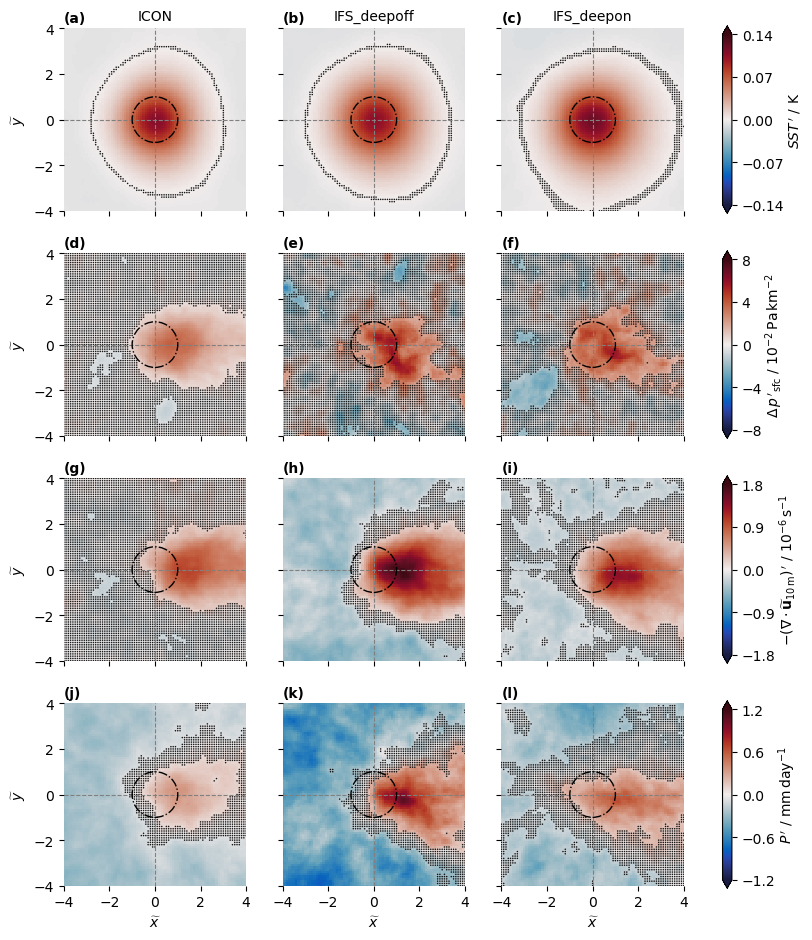

In [ ]:
# User settings
CRANGE = {
    'ts_ano': [-0.14, 0.14],
    'tas_ano': [-0.026, 0.026],
    'tas_ano_laplacian': [-0.6, 0.6],
    'ps_ano': [-0.5, 0.5],
    'ps_ano_laplacian': [-8, 8],
    'sfcwind_conv_ano': [-1.8, 1.8],
    'pr_ano': [-1.2, 1.2],
}
CLABEL = {
    'ts_ano': "$SST\,\mathrm{'}$ / K",
    'tas_ano': "tas",
    'tas_ano_laplacian': "$\Delta\,T\,\mathrm{'}_{\mathrm{2\,m}}$",
    'ps_ano_laplacian': "$\Delta\,p\,\mathrm{'}_{\mathrm{sfc}}$ / $10^{-2}\,\mathrm{Pa\,km^{-2}}$",
    'sfcwind_conv_ano': "$-\left(\\nabla\cdot\mathbf{\\widetilde{u}}_{\mathrm{10\,m}}\\right)\,\mathrm{'}$ / $10^{-6}\,\mathrm{s^{-1}}$",
    'pr_ano': "$P\,\mathrm{'}$ / $\mathrm{mm\,day^{-1}}$",
}
TITLES = {
    'ngc5004_opv4_w1': 'ICON',
    'ifs_tco3999-ng5_deepoff_opv0_w1': 'IFS_deepoff',
    'ifs_tco3999-ng5_rcbmf_opv0_w1': 'IFS_deepon',
}
VARLIST = ['ts_ano', 'ps_ano_laplacian', 'sfcwind_conv_ano', 'pr_ano']

# Plotting
fig, axes = hffig.init_subfig(
    style=None, asprat=(10, 11.2), nrow=4, ncol=3, sharex=True, sharey=True,
    )

for i, idf in enumerate(rb_compo_corrected.keys()):
    plot_data = rb_compo_corrected[idf]
    x = plot_data['En_rota2_featcen_x']
    y = plot_data['En_rota2_featcen_y']
    for j, var in enumerate(VARLIST):
        pl = axes[j, i].pcolormesh(
            x, y, plot_data[var].transpose(),
            vmin=CRANGE[var][0], vmax=CRANGE[var][1], cmap=cmocean.cm.balance,
            )
        
        pcplot.plot_sigmask(axes[j, i], rb_sigmask[idf][var])
        pcplot.plot_feature_grid(axes[j, i], x, y)
        pcplot.plot_feature_circle(axes[j, i], (0, 0), 1, lw=1)

        axes[j, i].set_aspect('equal')
        for spine in axes[j, i].spines.values():
            spine.set_visible(False)
        if i == 2:
            cb = fig.colorbar(
                pl, ax=axes[j, :], orientation='vertical', extend='both',
                ticks=np.linspace(CRANGE[var][0], CRANGE[var][1], 5),
                )
            cb.set_label(label=CLABEL[var], labelpad=1)

    axes[0, i].set_title(TITLES[idf], fontsize=10)

# Make plot nice
hffig.set_limit(axes, [-4, 4], [-4, 4])
hffig.set_ticks(axes, [-4, -2, 0, 2, 4], [-4, -2, 0, 2, 4])
hffig.set_label(axes, '$\\widetilde{x}$', '$\\widetilde{y}$')

# Save plot
outpath = Path(f'/home/m/m300738/project_TRR181L4/plots/paper/')
outpath.mkdir(parents=True, exist_ok=True)
outfile = Path('figure08.png')
plt.savefig(str(outpath/outfile), dpi=600, bbox_inches='tight')
plt.show()

### Plotting: Figure 09

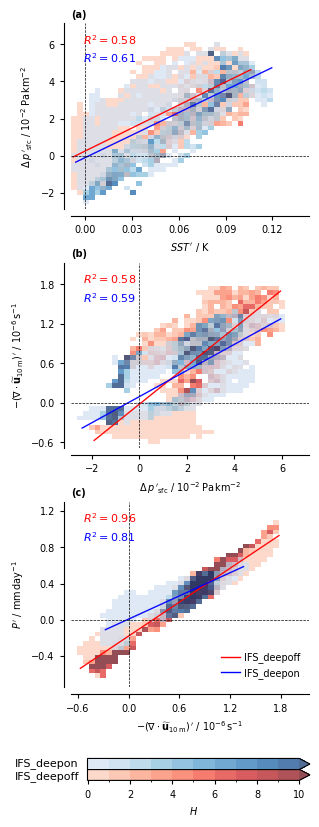

In [ ]:
from matplotlib.colors import BoundaryNorm
from scipy.stats import linregress

def get_bin_centers(bin_edges: np.ndarray) -> np.ndarray:
    return (bin_edges[:-1] + bin_edges[1:]) / 2

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    import matplotlib.colors as colors

    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap


# BASIC SETTINGS
CLABEL = {
    'ts_ano': "$SST\,\mathrm{'}$ / K",
    'tas_ano_laplacian': "$\Delta\,T\,\mathrm{'}_{\mathrm{2\,m}}$",
    'ps_ano_laplacian': "$\Delta\,p\,\mathrm{'}_{\mathrm{sfc}}$ / $10^{-2}\,\mathrm{Pa\,km^{-2}}$",
    'sfcwind_conv_ano': "$-\left(\\nabla\cdot\mathbf{\\widetilde{u}}_{\mathrm{10\,m}}\\right)\,\mathrm{'}$ / $10^{-6}\,\mathrm{s^{-1}}$",
    'pr_ano': "$P\,\mathrm{'}$ / $\mathrm{mm\,day^{-1}}$",
}
CMAP = {
    'ifs_tco3999-ng5_deepoff_opv0_w1': plt.get_cmap('Reds'),
    'ifs_tco3999-ng5_rcbmf_opv0_w1': plt.get_cmap('Blues'),
}
COLOR = {
    'ifs_tco3999-ng5_deepoff_opv0_w1': 'red',
    'ifs_tco3999-ng5_rcbmf_opv0_w1': 'blue',
}
LABELS = {
    'ifs_tco3999-ng5_deepoff_opv0_w1': 'IFS_deepoff',
    'ifs_tco3999-ng5_rcbmf_opv0_w1': 'IFS_deepon',
}
TICKS = {
    'ts_ano': [0.0, 0.03, 0.06, 0.09, 0.12],
    'ps_ano_laplacian': [-2, 0, 2, 4, 6],
    'sfcwind_conv_ano': [-0.6, 0, 0.6, 1.2, 1.8],
    'pr_ano': [-0.4, 0.0, 0.4, 0.8, 1.2]
}
Y_POS = {
    'ifs_tco3999-ng5_deepoff_opv0_w1': 0.95,
    'ifs_tco3999-ng5_rcbmf_opv0_w1': 0.85
}

COMBIS = [
    ('ts_ano', 'ps_ano_laplacian'),
    ('ps_ano_laplacian', 'sfcwind_conv_ano'),
    ('sfcwind_conv_ano', 'pr_ano'),
]

y_slice = slice(30, 51)
x_slice = slice(0, -1)
nbins_x = 40
nbins_y = 40

# create figure
fig, axes = hffig.init_subfig(
    style=('ams', 'one_column'),
    nrow=3, ncol=1, asprat=(3.2, 9), offset_x=5, offset_y=5
    )

for i, combi in enumerate(COMBIS):
    # Build shared bin edges from both experiments for this variable pair.
    x_all, y_all = [], []
    for exp, data in rb_compo_corrected.items():
        data = data.isel(y=y_slice).isel(x=x_slice)
        x_all.append(data[combi[0]].values.ravel())
        y_all.append(data[combi[1]].values.ravel())
    x_all = np.concatenate(x_all)
    y_all = np.concatenate(y_all)
    factor = 1.2
    xedges = np.linspace(
        factor*np.nanmin(x_all), factor*np.nanmax(x_all), nbins_x + 1
        )
    yedges = np.linspace(
        factor*np.nanmin(y_all), factor*np.nanmax(y_all), nbins_y + 1
        )

    # Set up axes
    ax = axes.ravel()[i]

    # MAIN LOGICAL LOOP OVER EXPERIMENTS
    for exp, data in rb_compo_corrected.items():
        if exp in ['ngc5004_opv4_w1']: continue

        # select x-data and y-data
        data = data.isel(y=y_slice).isel(x=x_slice)
        xvals = data[combi[0]].values.ravel()
        yvals = data[combi[1]].values.ravel()
        
        # calculate histogram
        hist2d, _, _ = np.histogram2d(xvals, yvals, bins=[xedges, yedges])
        hist_masked = np.ma.masked_where(hist2d.T == 0, hist2d)

        # create discrete colormap
        bounds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
        cmap_trunc = truncate_colormap(CMAP[exp], 0.2, 1.0)
        cmap = plt.get_cmap(cmap_trunc, len(bounds))
        norm = BoundaryNorm(bounds, cmap.N, extend="max")

        pl = ax.pcolormesh(
            xedges, yedges, hist_masked, cmap=cmap, norm=norm, alpha=0.7,
        )

        # create colorbars
        if i == 2:
            if exp == 'ifs_tco3999-ng5_rcbmf_opv0_w1':
                cb = fig.colorbar(
                    pl, ax=axes[2, :], orientation='horizontal',
                    ticks=[],
                    )
                cb.ax.minorticks_off()
            else:
                cb = fig.colorbar(
                    pl, ax=axes[2, :], orientation='horizontal',
                    ticks=[0, 2, 4, 6, 8, 10], label='$H$',
                    )
            
            if exp == 'ifs_tco3999-ng5_rcbmf_opv0_w1':
                pos = cb.ax.get_position()
                cb.ax.set_position(
                    [pos.x0+0.15, pos.y0-0.0457, pos.width-0.08, pos.height]
                    )
                ax.text(
                    -1.35, -1.61, 'IFS_deepon', color='k', fontsize=8, zorder=4,
                    bbox=dict(facecolor='none', alpha=0.75, edgecolor='none', pad=2),
                    )
            else:
                pos = cb.ax.get_position()
                cb.ax.set_position([pos.x0+0.15, pos.y0, pos.width-0.08, pos.height])
                ax.text(
                    -1.35, -1.76, 'IFS_deepoff', color='k', fontsize=8, zorder=4,
                    bbox=dict(facecolor='none', alpha=0.75, edgecolor='none', pad=2),
                    )


        # Regression
        res = linregress(xvals, yvals)
        xfit = np.linspace(np.nanmin(xvals), np.nanmax(xvals), 100)
        yfit = res.slope * xfit + res.intercept
        ax.plot(xfit, yfit, color=COLOR[exp], linewidth=1.0, alpha=0.95)
        ax.text(
            0.05, Y_POS[exp], f'$R^2 = {(res.rvalue**2):.2f}$', color=COLOR[exp],
            transform=ax.transAxes, fontsize=8, verticalalignment='top',
        )

    ax.set_xlabel(CLABEL[combi[0]])
    ax.set_ylabel(CLABEL[combi[1]])
    ax.set_xticks(TICKS[combi[0]])
    ax.set_yticks(TICKS[combi[1]])

    ax.axvline(0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(0, color='k', linestyle='--', linewidth=0.5)
    
legend_handles = []
for exp in LABELS:
    legend_handles.append(
        plt.Line2D([0], [0], color=COLOR[exp], label=LABELS[exp])
    )

plt.legend(
    handles=legend_handles, loc='lower right', ncol=1, frameon=False,
    columnspacing=1.2, handletextpad=0.4,
    )

plt.tight_layout()
fig.subplots_adjust(bottom=0.235)

# Save plot
outpath = Path(f'/home/m/m300738/project_TRR181L4/plots/paper/')
outpath.mkdir(parents=True, exist_ok=True)
outfile = Path('figure09.png')
plt.savefig(str(outpath/outfile), dpi=600, bbox_inches='tight')
plt.show()